# ZEPTO DATA & AI PLATFORM

## Module 2 — Analytics Pipeline
### Part A — Profiling, Cleaning & Data Story

This notebook loads, profiles, cleans, and analyzes the Titanic dataset.

Pipeline:

Load Dataset
→ Profile Data
→ Handle Missing Values
→ Univariate Analysis
→ Bivariate Analysis
→ Multivariate Data Story
→ Standardization Check
→ Save Cleaned Dataset

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set_theme(style="whitegrid")

## 2. Load Titanic Dataset

The dataset is loaded using Seaborn's built-in Titanic loader.

This is the only point in the entire project where the raw Titanic
dataset is loaded from Seaborn.

In [ ]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 15)


In [ ]:
df.to_csv("titanic.csv", index=False)

print("Offline fallback saved as titanic.csv")
pd.read_csv("titanic.csv")

Offline fallback saved as titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## 3. Initial Data Profiling

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

Dataset Shape:
(891, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Descriptive Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Missing Value Analysis

In [ ]:
missing_summary = (
    df.isnull()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
)

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

missing_summary

,missing_count,missing_percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


### Missing-Value Strategy

The missing-value strategy follows the required threshold:

- Missingness below 5% → drop affected rows.
- Missingness from 5% to 30% → impute the missing values.
- Very high missingness → evaluate whether the column should be dropped
  or whether "missing" should be treated as its own category.

The exact missing percentages measured above are used to justify
the strategy applied to each affected column.

In [ ]:
df[missing_summary.index].head(10)

,deck,age,embarked,embark_town
0,NaN,22.0,S,Southampton
1,C,38.0,C,Cherbourg
2,NaN,26.0,S,Southampton
3,C,35.0,S,Southampton
4,NaN,35.0,S,Southampton
5,NaN,NaN,Q,Queenstown
6,E,54.0,S,Southampton
7,NaN,2.0,S,Southampton
8,NaN,27.0,S,Southampton
9,NaN,14.0,C,Cherbourg


In [ ]:
missing_percentages = (
    df.isnull().mean() * 100
)

missing_percentages = (
    missing_percentages[
        missing_percentages > 0
    ]
    .sort_values(ascending=False)
)

missing_percentages

,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


## 5. Missing-Value Handling

In [ ]:
df = df.drop(columns=["deck"])

print("Dropped 'deck' because its missingness is too high for reliable imputation.")

Dropped 'deck' because its missingness is too high for reliable imputation.


In [ ]:
age_median = df["age"].median()

df["age"] = df["age"].fillna(age_median)

print("Age missing values after imputation:",
      df["age"].isnull().sum())

Age missing values after imputation: 0


In [ ]:
embarked_mode = df["embarked"].mode()[0]

df["embarked"] = df["embarked"].fillna(embarked_mode)

print("Embarked missing values after imputation:",
      df["embarked"].isnull().sum())

Embarked missing values after imputation: 0


In [ ]:
embark_town_mode = df["embark_town"].mode()[0]

df["embark_town"] = df["embark_town"].fillna(
    embark_town_mode
)

print(
    "embark_town missing values after imputation:",
    df["embark_town"].isnull().sum()
)

embark_town missing values after imputation: 0


In [ ]:
remaining_missing = (
    df.isnull()
      .sum()
)

remaining_missing = (
    remaining_missing[
        remaining_missing > 0
    ]
)

remaining_missing

,0


In [ ]:
df.to_csv("titanic.csv", index=False)

print("Cleaned Titanic dataset saved successfully.")
print("Shape:", df.shape)

Cleaned Titanic dataset saved successfully.
Shape: (891, 14)


## 6. Univariate Analysis — Age

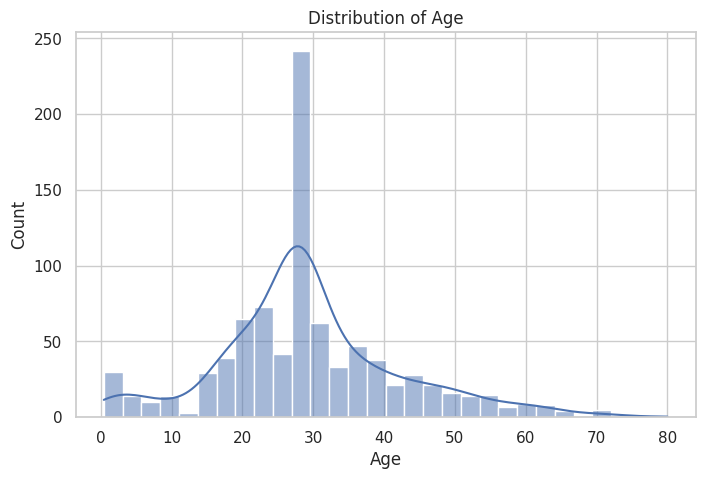

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

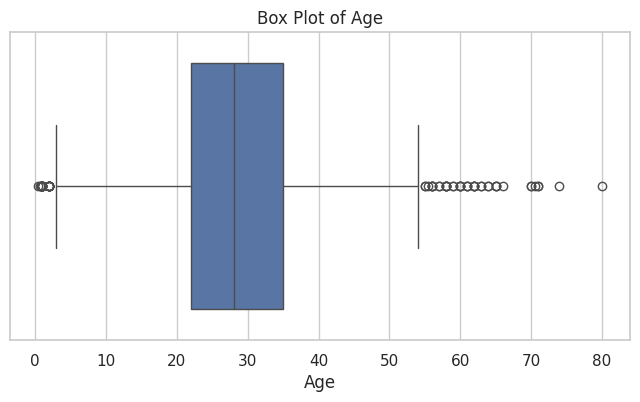

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["age"]
)

plt.title("Box Plot of Age")
plt.xlabel("Age")

plt.show()

## 7. Univariate Analysis — Fare

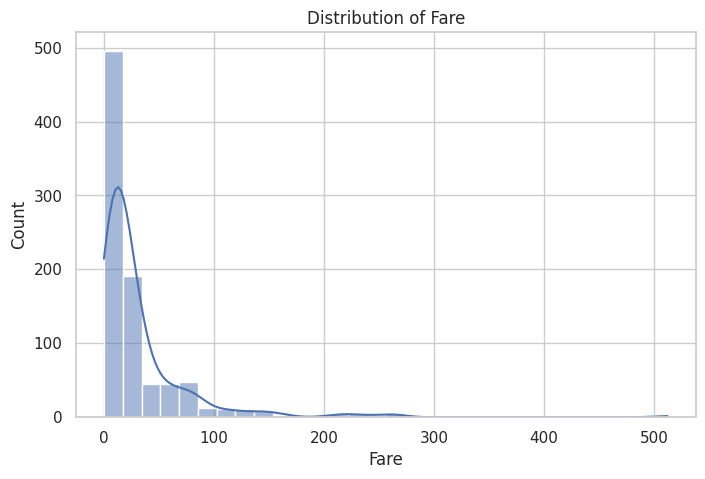

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["fare"],
    bins=30,
    kde=True
)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

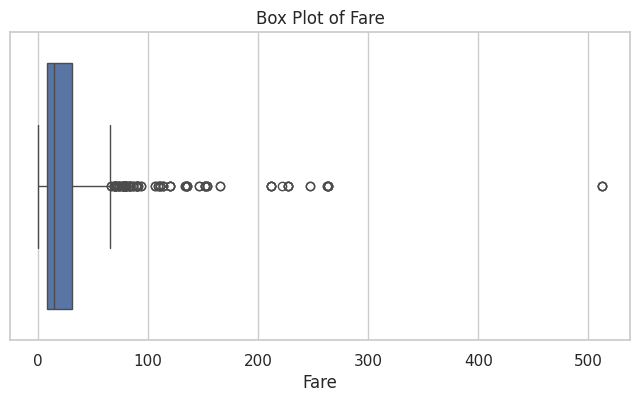

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["fare"]
)

plt.title("Box Plot of Fare")
plt.xlabel("Fare")

plt.show()

## 8. IQR-Based Outlier Detection

In [ ]:
def count_iqr_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    return outliers.sum(), lower_bound, upper_bound

In [ ]:
age_outliers, age_lower, age_upper = count_iqr_outliers(
    df["age"]
)

fare_outliers, fare_lower, fare_upper = count_iqr_outliers(
    df["fare"]
)

print("Age")
print("Outliers:", age_outliers)
print("Lower bound:", age_lower)
print("Upper bound:", age_upper)

print("\nFare")
print("Outliers:", fare_outliers)
print("Lower bound:", fare_lower)
print("Upper bound:", fare_upper)

Age
Outliers: 66
Lower bound: 2.5
Upper bound: 54.5

Fare
Outliers: 116
Lower bound: -26.724
Upper bound: 65.6344


### Outlier Interpretation

The IQR rule identifies the number of observations outside the
lower and upper bounds for age and fare.

These observations are reported as statistical outliers rather than
automatically removed. The presence of an outlier does not by itself
justify deleting a data point.

## 9. Fare Distribution Statistics

In [ ]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.204207968574636
Fare Median: 14.4542
Fare Mode: 8.05


In [ ]:
print(
    "Mean > Median:",
    fare_mean > fare_median
)

print(
    "Median > Mode:",
    fare_median > fare_mode
)

Mean > Median: True
Median > Mode: True


### Fare Distribution Interpretation

The mean fare is higher than the median fare, while the mode is lower
than the median. This ordering indicates a right-skewed distribution,
which is also visible in the histogram because a relatively small
number of passengers paid substantially higher fares.

## 10. Bivariate Analysis

We now examine how individual passenger characteristics relate
to survival.

### 10.1 Survival Rate by Sex

In [ ]:
male_survival = df.loc[
    df["sex"] == "male",
    "survived"
].mean()

female_survival = df.loc[
    df["sex"] == "female",
    "survived"
].mean()

print("Male survival rate:", male_survival)
print("Female survival rate:", female_survival)
print(
    "Male survival rate:",
    round(male_survival * 100, 2),
    "%"
)

print(
    "Female survival rate:",
    round(female_survival * 100, 2),
    "%"
)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7420382165605095
Male survival rate: 18.89 %
Female survival rate: 74.2 %


### 10.2 Survival Rate by Passenger Class

In [ ]:
first_class_survival = df.loc[
    df["pclass"] == 1,
    "survived"
].mean()

second_class_survival = df.loc[
    df["pclass"] == 2,
    "survived"
].mean()

third_class_survival = df.loc[
    df["pclass"] == 3,
    "survived"
].mean()

print(
    "1st class:",
    round(first_class_survival * 100, 2),
    "%"
)

print(
    "2nd class:",
    round(second_class_survival * 100, 2),
    "%"
)

print(
    "3rd class:",
    round(third_class_survival * 100, 2),
    "%"
)

1st class: 62.96 %
2nd class: 47.28 %
3rd class: 24.24 %


### 10.3 Survival Rate by Sex and Passenger Class

In [ ]:
female_first = df.loc[
    (df["sex"] == "female") &
    (df["pclass"] == 1),
    "survived"
].mean()

female_second = df.loc[
    (df["sex"] == "female") &
    (df["pclass"] == 2),
    "survived"
].mean()

female_third = df.loc[
    (df["sex"] == "female") &
    (df["pclass"] == 3),
    "survived"
].mean()

male_first = df.loc[
    (df["sex"] == "male") &
    (df["pclass"] == 1),
    "survived"
].mean()

male_second = df.loc[
    (df["sex"] == "male") &
    (df["pclass"] == 2),
    "survived"
].mean()

male_third = df.loc[
    (df["sex"] == "male") &
    (df["pclass"] == 3),
    "survived"
].mean()

print("Female, 1st class:", round(female_first * 100, 2), "%")
print("Female, 2nd class:", round(female_second * 100, 2), "%")
print("Female, 3rd class:", round(female_third * 100, 2), "%")

print()

print("Male, 1st class:", round(male_first * 100, 2), "%")
print("Male, 2nd class:", round(male_second * 100, 2), "%")
print("Male, 3rd class:", round(male_third * 100, 2), "%")

Female, 1st class: 96.81 %
Female, 2nd class: 92.11 %
Female, 3rd class: 50.0 %

Male, 1st class: 36.89 %
Male, 2nd class: 15.74 %
Male, 3rd class: 13.54 %


### 10.4 Combined Survival Rate Table

In [ ]:
survival_by_sex_class = (
    df.groupby(["sex", "pclass"])["survived"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name="survival_rate_percent")
)

survival_by_sex_class

,sex,pclass,survival_rate_percent
0,female,1,96.81
1,female,2,92.11
2,female,3,50.00
3,male,1,36.89
4,male,2,15.74
5,male,3,13.54


## 11. Correlation Analysis

In [ ]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[
    correlation_columns
].corr()

correlation_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


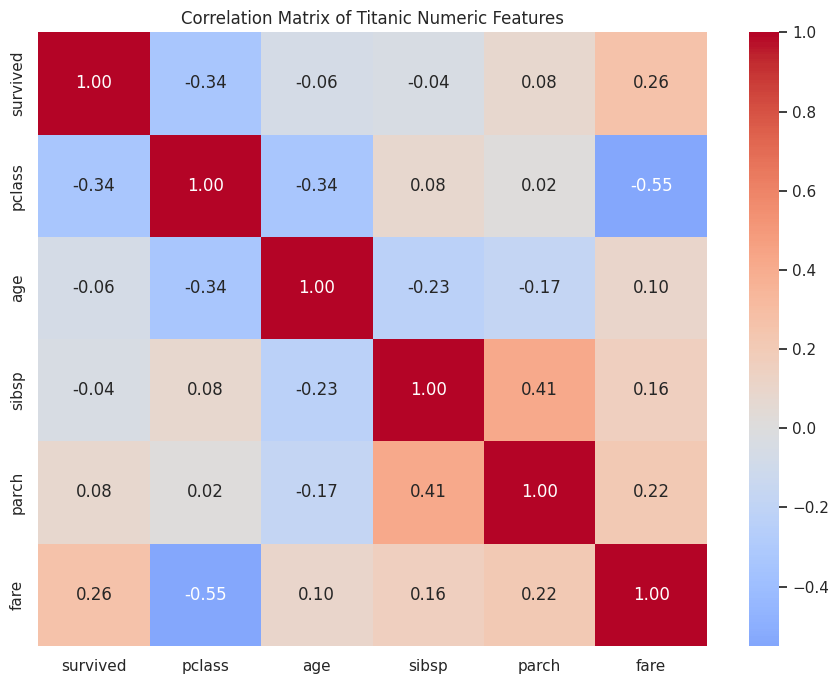

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Titanic Numeric Features")
plt.tight_layout()

plt.show()

### 11.1 Strongest Correlations

The two strongest correlations are identified using the absolute value
of the off-diagonal correlation coefficients.

The diagonal values of 1.0 are excluded because they represent each
variable's correlation with itself.

In [ ]:
corr_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):

        feature_1 = correlation_columns[i]
        feature_2 = correlation_columns[j]

        correlation = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        corr_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation": correlation,
            "absolute_correlation": abs(correlation)
        })

strongest_correlations = (
    pd.DataFrame(corr_pairs)
      .sort_values(
          "absolute_correlation",
          ascending=False
      )
      .head(2)
)

strongest_correlations

,feature_1,feature_2,correlation,absolute_correlation
8,pclass,fare,-0.549500,0.549500
12,sibsp,parch,0.414838,0.414838


## 12. Multivariate Data Story

The following visualizations examine survival patterns across
multiple passenger characteristics.

Each visualization is followed by a short interpretation.

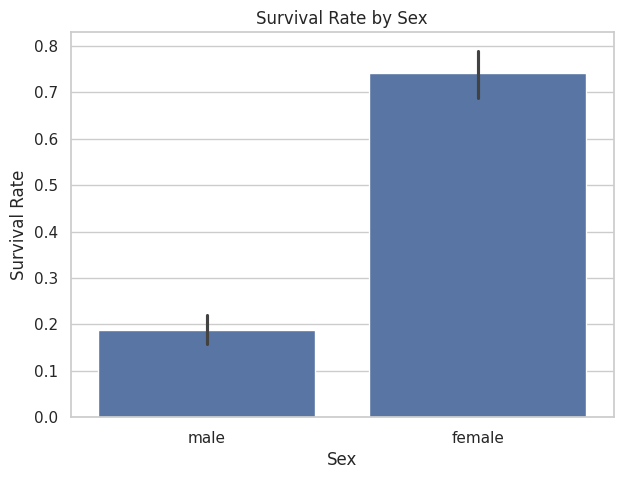

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation — Survival by Sex

The chart shows a substantial difference in survival rates between
female and male passengers. Female passengers had a survival rate of
74.20%, compared with 18.89% for male passengers. This indicates that
sex is strongly associated with survival in this dataset, although
the analysis itself does not establish causation.

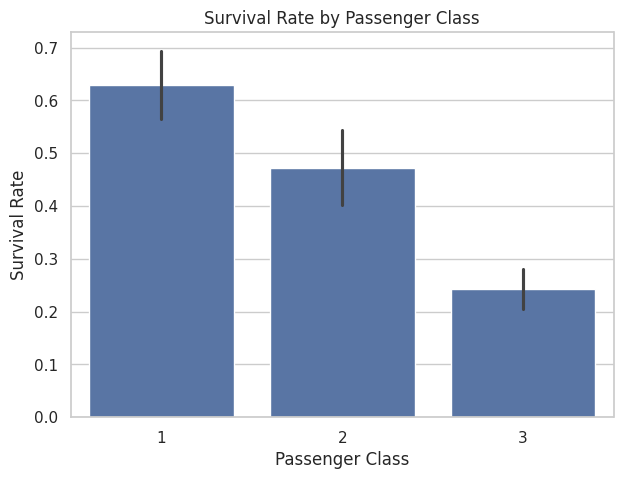

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation — Survival by Passenger Class

Survival rates differ across passenger classes. The survival rate was
62.96% for first-class passengers, 47.28% for second-class passengers,
and 24.24% for third-class passengers. The chart therefore shows a
clear association between passenger class and survival in this dataset.

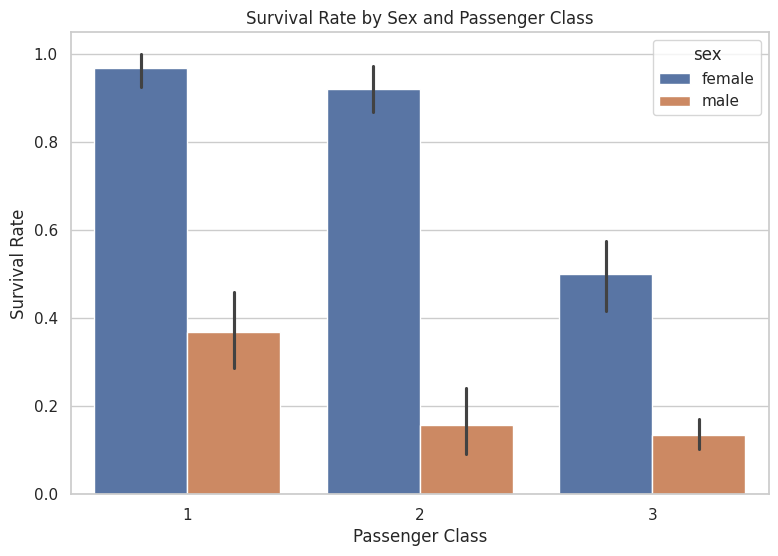

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation — Sex and Passenger Class

Survival differs across both sex and passenger class. Female survival
was 96.81% in first class, 92.11% in second class, and 50.00% in third
class, while male survival was 36.89%, 15.74%, and 13.54% respectively.
This shows that examining sex and passenger class together provides
more detail than examining either variable independently.

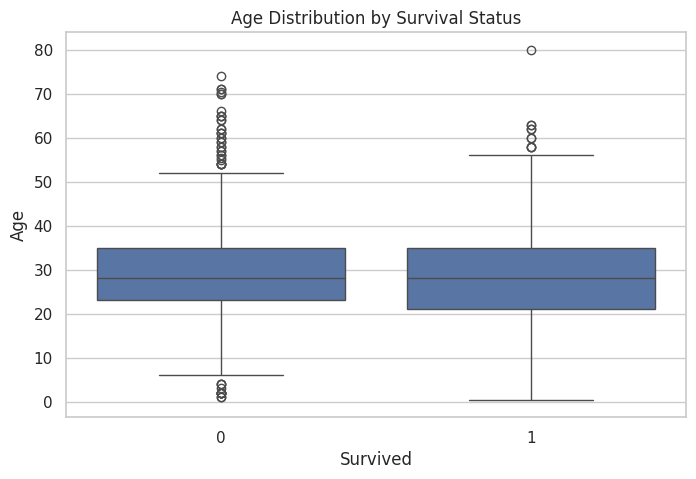

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.show()

### Interpretation — Age and Survival

The box plot compares the age distributions of passengers who survived
and those who did not. The distributions overlap substantially, showing
that age alone does not completely separate the two survival groups.
However, the plot allows differences in the central tendency and spread
of age between the groups to be examined.

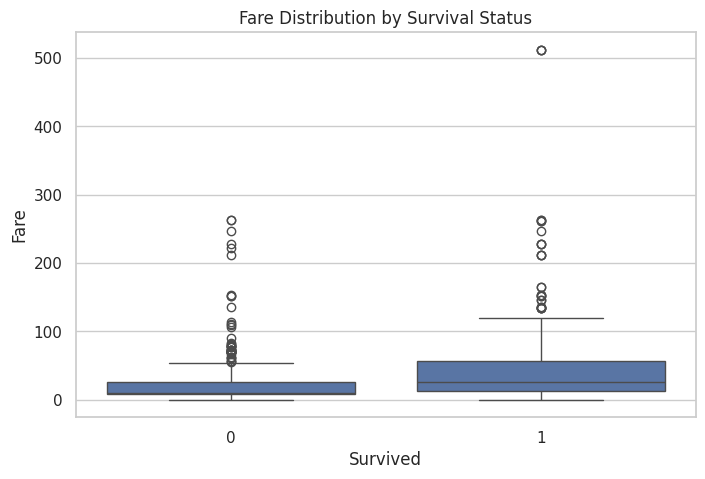

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

### Interpretation — Fare and Survival

The fare distributions differ between the survival groups, with the
surviving group generally showing higher fare values. This is consistent
with the observed relationship between passenger class and fare, since
passenger class and fare are moderately negatively correlated in the
dataset.

## 13. Correlation Findings

In [ ]:
correlation_findings = strongest_correlations[
    [
        "feature_1",
        "feature_2",
        "correlation"
    ]
].copy()

correlation_findings

,feature_1,feature_2,correlation
8,pclass,fare,-0.549500
12,sibsp,parch,0.414838


### Interpretation

The strongest correlation among the six selected numerical variables
is between 'pclass' and 'fare', with a correlation of approximately
-0.55. This indicates a moderate negative linear relationship.

The second strongest correlation is between 'sibsp' and 'parch',
with a correlation of approximately 0.41, indicating a moderate
positive linear relationship.

These are associations within the dataset and should not be interpreted
as evidence of causal relationships.

## 14. Standardization Check

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    df[numeric_features]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=numeric_features
)

scaled_df.head()

,pclass,age,sibsp,parch,fare
0,0.827377,-0.565736,0.432793,-0.473674,-0.502445
1,-1.566107,0.663861,0.432793,-0.473674,0.786845
2,0.827377,-0.258337,-0.474545,-0.473674,-0.488854
3,-1.566107,0.433312,0.432793,-0.473674,0.420730
4,0.827377,0.433312,-0.474545,-0.473674,-0.486337


In [ ]:
print("Means after standardization:")
print(scaled_df.mean().round(6))

print("\nStandard deviations after standardization:")
print(scaled_df.std().round(6))

Means after standardization:
pclass   -0.0
age       0.0
sibsp     0.0
parch     0.0
fare      0.0
dtype: float64

Standard deviations after standardization:
pclass    1.000562
age       1.000562
sibsp     1.000562
parch     1.000562
fare      1.000562
dtype: float64


### Standardization Interpretation

Standardization transforms numerical predictor variables so that they
are placed on a comparable scale.

The target variable 'survived' is not standardized because it represents
the outcome that the models will predict.

In the modeling pipeline, the scaler will be fitted only on the
training data to prevent information from the test set from influencing
the preprocessing step.

## 15. Final EDA Summary

### Key Findings

1. The dataset contains 891 observations and 15 original columns.

2. 'deck' has very high missingness (77.22%) and is therefore removed.

3. 'age' has 19.87% missing values and is median-imputed.

4. 'embarked' and 'embark_town' each have 0.22% missing values and are
   imputed using their respective modes.

5. Fare is right-skewed, with:
   - Mean = 32.20
   - Median = 14.45
   - Mode = 8.05

6. The IQR method identifies 66 age outliers and 116 fare outliers.

7. Survival differs substantially by sex and passenger class.

8. The strongest correlation among the required six numerical variables
   is between pclass and 'fare' (-0.5495).

9. The second strongest correlation is between 'sibsp' and 'parch''
   (0.4148).

10. Standardization is appropriate for numerical predictor variables,
    while the target variable `survived` should remain unstandardized.

In [ ]:
print("Final dataset shape:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nFinal columns:")
print(df.columns.tolist())

Final dataset shape: (891, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Final columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [ ]:
df = pd.read_csv("titanic.csv")

In [ ]:
from google.colab import files
files.download("titanic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>